sprint 11
localhost 3306
root
password
transactions_sprint_4_1


In [1]:
!pip install seaborn matplotlib plotly pandas squarify dotenv mysql-connector-python

import squarify
from matplotlib.ticker import FuncFormatter
import numpy as np
from mysql.connector.abstracts import MySQLConnectionAbstract
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
import mysql.connector
from mysql.connector import Error


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
load_dotenv()

host = os.getenv("MYSQL_HOST")
port = os.getenv("MYSQL_PORT")
user = os.getenv("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
database = os.getenv("MYSQL_DATABASE")

config = {
  'user': user,
  'password': password,
  'host': host,
  'database': database,
    'port': port,
  'raise_on_warnings': True
}

def get_connection():
    return mysql.connector.connect(**config)


In [3]:
try:
    connection = get_connection()
    cursor = connection.cursor()
    query = "SELECT DATABASE();"
    cursor.execute(query)
    db_name = cursor.fetchone()
    print("Connected to: ", db_name)

except Error as e:
    print(e)

finally:
    if connection.is_connected():
        cursor.close()
        connection.close()
    print("Disconnected from database")


Connected to:  ('transactions_sprint_4_1',)
Disconnected from database


In [4]:
def get_dataframe(query):
    try:
        connection = get_connection()
        return pd.read_sql(query, connection)
    except Error as e:
        print(e)
    finally:
        if connection.is_connected():
            connection.close()


In [5]:

tables = get_dataframe("SHOW TABLES")
tables

C:\Users\raari\AppData\Local\Temp\ipykernel_38888\151428039.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection)


,Tables_in_transactions_sprint_4_1
0,card_status
1,companies
2,credit_cards
3,products
4,transactions
5,transactions_products
6,users


In [6]:
dictionary_of_dfs = {}
for df_name in tables.iloc[:, 0]:
    dictionary_of_dfs[df_name] = get_dataframe(f"SELECT * FROM {df_name}")
    print(f" - {df_name} loaded: {dictionary_of_dfs[df_name].size} rows")


C:\Users\raari\AppData\Local\Temp\ipykernel_38888\151428039.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection)


 - card_status loaded: 10000 rows
 - companies loaded: 600 rows
 - credit_cards loaded: 45000 rows
 - products loaded: 600 rows
 - transactions loaded: 1000000 rows
 - transactions_products loaded: 506782 rows
 - users loaded: 50000 rows


deshago para trabajar mas comoda los nombres de lo df


In [7]:

companies = dictionary_of_dfs['companies']
credit_cards = dictionary_of_dfs['credit_cards']
card_status = dictionary_of_dfs['card_status']
products = dictionary_of_dfs['products']
transactions = dictionary_of_dfs['transactions']
transactions_products = dictionary_of_dfs['transactions_products']
users = dictionary_of_dfs['users']

#### 1 variable numerica

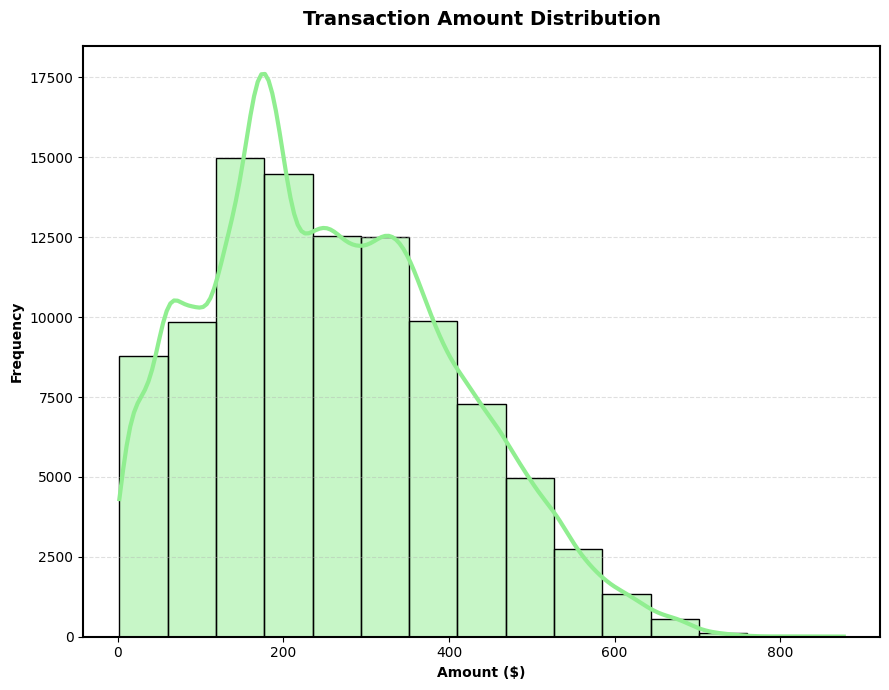

In [8]:


def draw_transaction_amount_distribution():
    # Data cleaning
    data = pd.to_numeric(dictionary_of_dfs["transactions"]['amount'], errors='coerce').dropna()

    # Figure and plot configuration
    plt.figure(figsize=(9, 7))
    ax = sns.histplot(data, bins=15, color='lightgreen', edgecolor='black', kde=True,
                      line_kws={'color': '#1b5e20', 'linewidth': 3})

    # Frame and Grid setup (ONLY Horizontal)
    plt.setp(ax.spines.values(), visible=True, linewidth=1.5)
    ax.xaxis.grid(False) # Explicitly disable vertical grid
    ax.yaxis.grid(True, linestyle='--', alpha=0.4) # Enable only horizontal grid

    # Titles and labels
    plt.title("Transaction Amount Distribution", fontsize=14, weight='bold', pad=15)
    plt.xlabel("Amount ($)", weight='bold')
    plt.ylabel("Frequency", weight='bold')

    plt.tight_layout()
    plt.show()

draw_transaction_amount_distribution()

#### 2 numericas


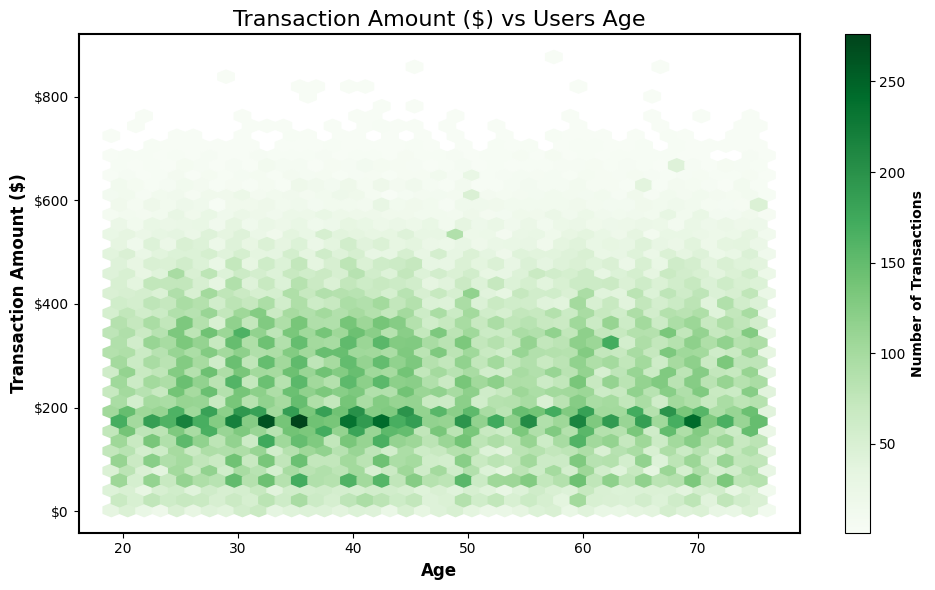

Conclusion: This hexbin plot illustrates the density of transaction spending across user ages. Darker green areas represent age groups with higher transaction frequency and specific spending patterns.


In [9]:

# Age calculation
users['birth_date'] = pd.to_datetime(users['birth_date'], errors='coerce')
current_date = pd.Timestamp.today()
users['age'] = (current_date - users['birth_date']).dt.days // 365

# Data Merging
sales_df= transactions.merge(users, on='user_id', how='inner')

# Visualization Setup
fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(
    sales_df['age'],
    sales_df['amount'],
    gridsize=40,
    cmap='Greens',
    mincnt=1
)

# --- FRAME AND GRID SETTINGS ---
ax.grid(False)  # Remove any background grid
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)


# Titles and Axis Labels
ax.set_title('Transaction Amount ($) vs Users Age', fontsize=16)
ax.set_xlabel('Age', fontsize=12, weight='bold')
ax.set_ylabel('Transaction Amount ($)', fontsize=12, weight='bold')

# Format Y-axis as currency
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f'${val:,.0f}'.replace(',', '.')))

# Colorbar setup
colorbar = fig.colorbar(hb, ax=ax)
colorbar.set_label('Number of Transactions', weight='bold')

plt.tight_layout()
plt.show()

print(
    "Conclusion: This hexbin plot illustrates the density of transaction spending across user ages. "
    "Darker green areas represent age groups with higher transaction frequency and specific spending patterns."
)

### 1 categorica

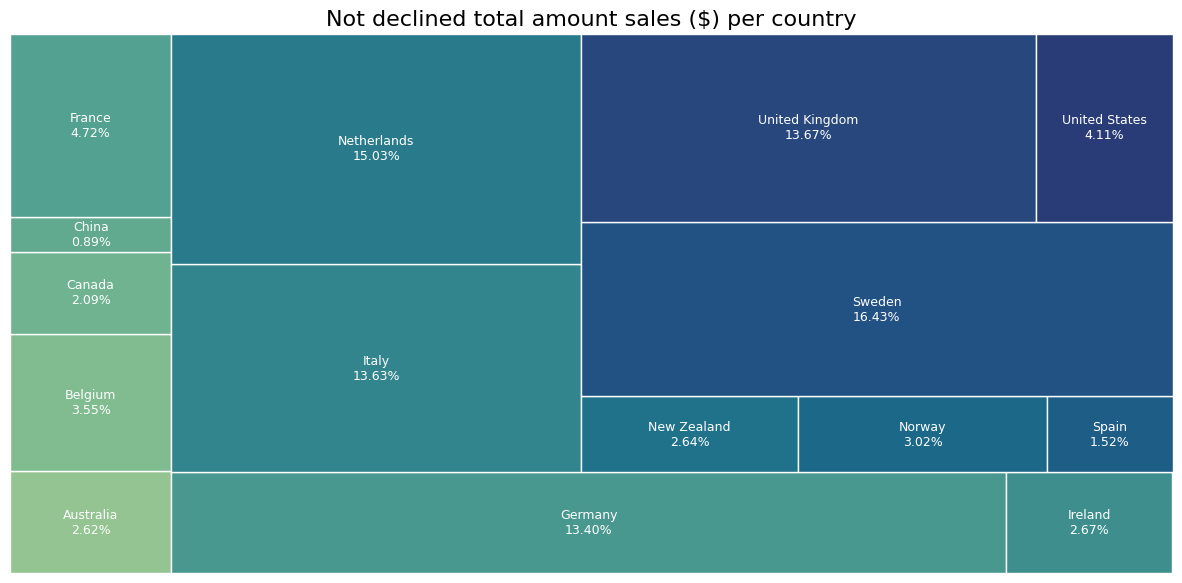

In [10]:

accepted_transactions = transactions[transactions['declined'] == 0]

transactions_with_companies = accepted_transactions.merge(
    companies[['company_id', 'country']],
    on='company_id',
    how='left'
)

country_sales_sum = transactions_with_companies.groupby('country')['amount'].sum().reset_index()
total_amount = country_sales_sum['amount'].sum()
percentages = [(amount / total_amount) * 100 for amount in country_sales_sum['amount']]

sizes = country_sales_sum['amount']
labels = country_sales_sum['country']

fig, ax = plt.subplots(figsize=(15, 7))

colors = sns.color_palette("crest", len(sizes))

squarify.plot(
    sizes=sizes,
    label=[f"{country}\n{pct:.2f}%" for country, pct in zip(labels, percentages)],
    color=colors,
    ax=ax,
    edgecolor='white',
    text_kwargs={'color': 'white', 'fontsize': 9}
)

plt.title("Not declined total amount sales ($) per country", fontsize=16)
plt.axis('off')

plt.show()


#### 1 cat y 1 numerica

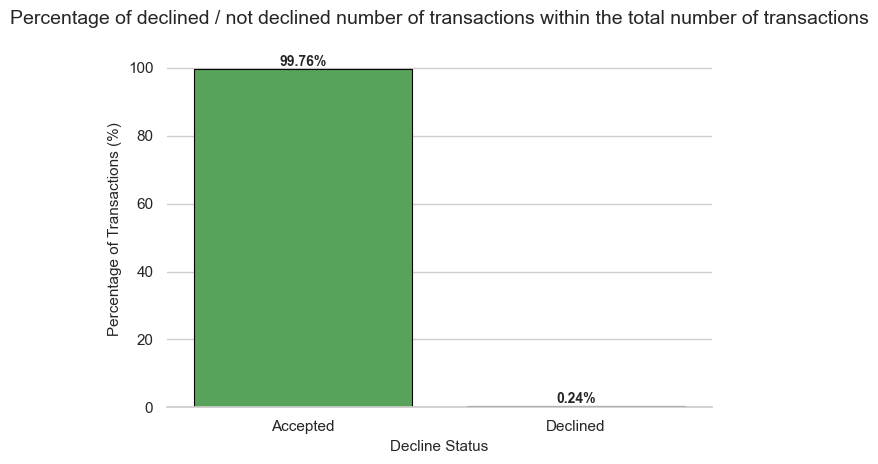

Total Transactions: 100000
Accepted Transactions: 99763 (99.76%)
Declined Transactions: 237 (0.24%)


In [11]:

total_transactions = len(transactions)
declined_count = len(transactions[transactions['declined'] == 1])
accepted_count = len(transactions[transactions['declined'] == 0])

declined_percentage = (declined_count / total_transactions) * 100
accepted_percentage = (accepted_count / total_transactions) * 100

# Create a DataFrame for the barplot
df_percentages = pd.DataFrame({
    "decline_status": ["Accepted", "Declined"],
    "percentage": [accepted_percentage, declined_percentage]
})

sns.set_theme(style="whitegrid")

custom_palette = ["#4CAF50", "#E53935"]

barplot = sns.barplot(
    data=df_percentages,
    x="decline_status",
    y="percentage",
    hue="decline_status",
    palette=custom_palette,
    errorbar=None,
    edgecolor="black",
    linewidth=0.8
)

barplot.set_title("Percentage of declined / not declined number of transactions within the total number of transactions", fontsize=14, pad=20)
barplot.set_xlabel("Decline Status", fontsize=11)
barplot.set_ylabel("Percentage of Transactions (%)", fontsize=11)

# Remove legend only if it exists
if barplot.legend_:
    barplot.legend_.remove()

for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(
        f"{height:.2f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        weight="semibold"
    )

sns.despine(ax=barplot, left=True)

plt.tight_layout()
plt.show()


print(f"Total Transactions: {total_transactions}")
print(f"Accepted Transactions: {accepted_count} ({accepted_percentage:.2f}%)")
print(f"Declined Transactions: {declined_count} ({declined_percentage:.2f}%)")

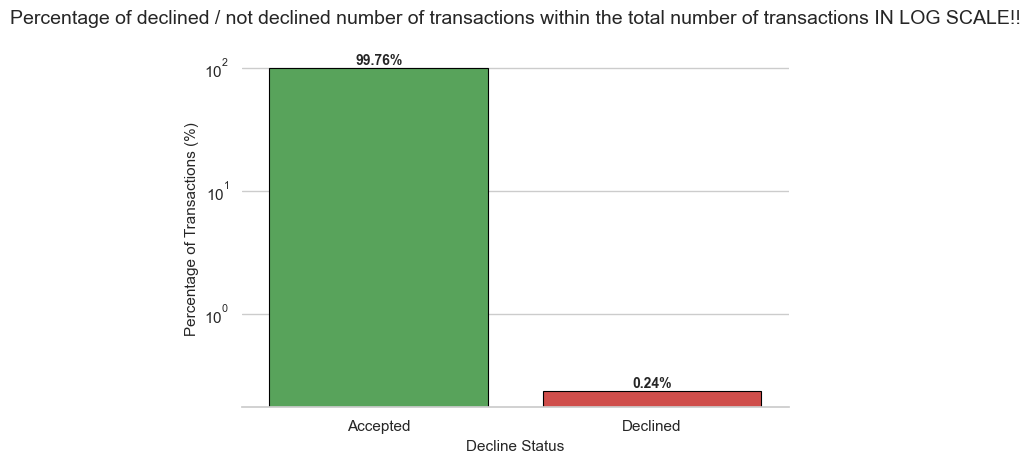

Total Transactions: 100000
Accepted Transactions: 99763 (99.76%)
Declined Transactions: 237 (0.24%)


In [12]:
total_transactions = len(transactions)
declined_count = len(transactions[transactions['declined'] == 1])
accepted_count = len(transactions[transactions['declined'] == 0])

declined_percentage = (declined_count / total_transactions) * 100
accepted_percentage = (accepted_count / total_transactions) * 100

df_percentages = pd.DataFrame({
    "decline_status": ["Accepted", "Declined"],
    "percentage": [accepted_percentage, declined_percentage]
})


sns.set_theme(style="whitegrid")

custom_palette = ["#4CAF50", "#E53935"]

barplot = sns.barplot(
    data=df_percentages,
    x="decline_status",
    y="percentage",
    hue="decline_status",
    palette=custom_palette,
    errorbar=None,
    edgecolor="black",
    linewidth=0.8
)

barplot.set_title("Percentage of declined / not declined number of transactions within the total number of transactions IN LOG SCALE!!", fontsize=14, pad=20)
barplot.set_xlabel("Decline Status", fontsize=11)
barplot.set_ylabel("Percentage of Transactions (%)", fontsize=11)

# Apply logarithmic scale to Y-axis
barplot.set_yscale("log")

# Remove legend only if it exists
if barplot.legend_:
    barplot.legend_.remove()

for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(
        f"{height:.2f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        weight="semibold"
    )

sns.despine(ax=barplot, left=True)

plt.tight_layout()
plt.show()


print(f"Total Transactions: {total_transactions}")
print(f"Accepted Transactions: {accepted_count} ({accepted_percentage:.2f}%)")
print(f"Declined Transactions: {declined_count} ({declined_percentage:.2f}%)")

### 2 categoricas

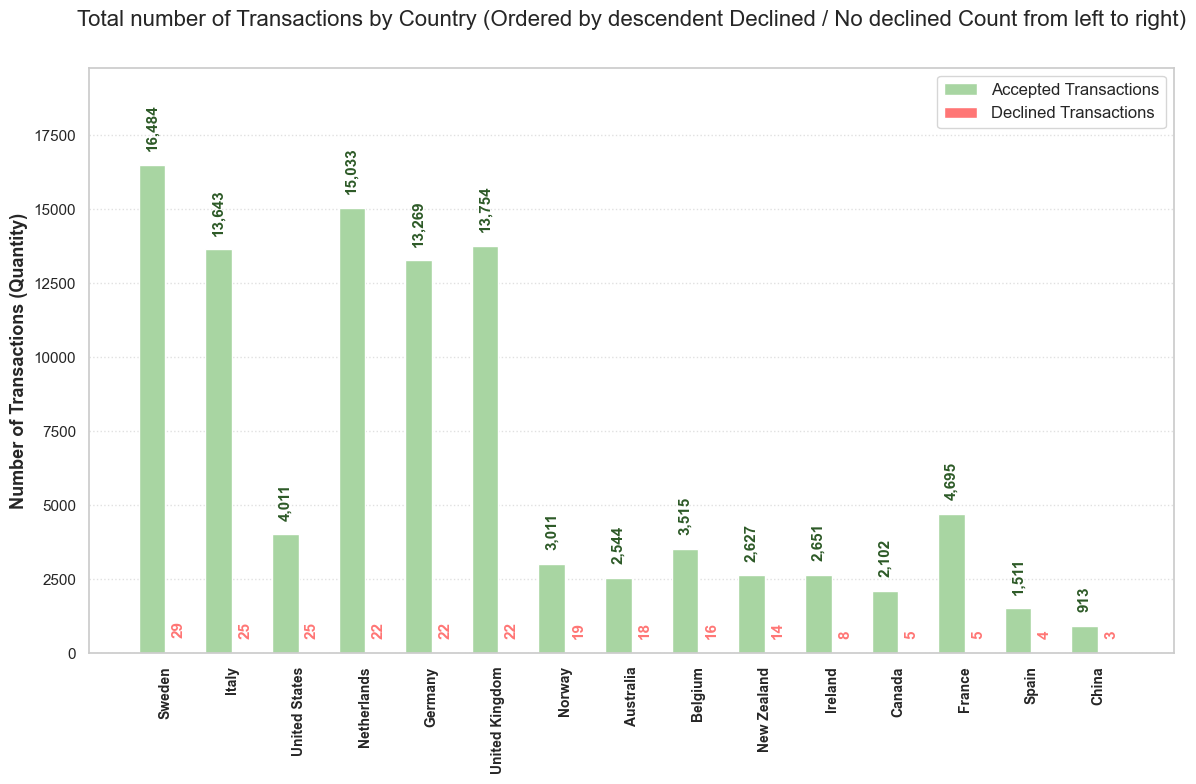

In [13]:

# Merge transactions with companies to include the 'country' column
df = transactions.merge(companies[['company_id', 'country']], on='company_id', how='left')

# Aggregation: Transaction COUNT (using count instead of sum)
# Group by country and status, then pivot to have 'Accepted' and 'Declined' as columns
pivot_df = df.groupby(['country', 'declined'])['transaction_id'].count().unstack(fill_value=0)
pivot_df.columns = ['Accepted', 'Declined']

# Sort by the number of 'Declined' transactions in descending order
pivot_df = pivot_df.sort_values(by='Declined', ascending=False)

# Plot
countries = pivot_df.index
x = np.arange(len(countries))
width = 0.4
fig, ax = plt.subplots(figsize=(12, 8))
rects1 = ax.bar(x - width/2, pivot_df['Accepted'], width, label='Accepted Transactions', color='#a8d5a2')
rects2 = ax.bar(x + width/2, pivot_df['Declined'], width, label='Declined Transactions', color='#ff7675')
ax.set_ylabel('Number of Transactions (Quantity)', fontsize=13, fontweight='bold')
ax.set_title('Total number of Transactions by Country (Ordered by descendent Declined / No declined Count from left to right)', fontsize=16, pad=30)
ax.set_xticks(x)
ax.set_xticklabels(countries, rotation=90, fontweight='bold', fontsize=10)

# Labeling Function (Integers with larger font size)
def add_labels(rects, text_color):
    """Adds data labels on top of each bar"""
    for rect in rects:
        height = rect.get_height()
        if height >= 0:
            # Format as integer with thousands separator
            label = f"{int(height):,}"
            ax.annotate(label,
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 10),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        rotation=90,
                        color=text_color,
                        fontsize=11,
                        fontweight='bold')

# Apply labels with specific colors: Dark Green and Red
add_labels(rects1, '#2d5a27')
add_labels(rects2, '#ff7675')

# Grid Customization (Dotted Grid)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)

# Adjust Y-axis limit
ax.set_ylim(0, pivot_df['Accepted'].max() * 1.2)

ax.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

#### 3 variable combinadas

¿Cómo leer este gráfico?
El ancho del violín: Representa la frecuencia. Si el violín es muy "gordo" en la parte inferior, significa que la gran mayoría de las transacciones son de montos bajos.

La separación (Split): Al usar split=True, comparas directamente en el mismo eje la distribución de las ventas exitosas vs. las fallidas. Por ejemplo, podrías notar que las transacciones rechazadas suelen ser de montos mucho más altos que las aceptadas.

Líneas internas: Las líneas punteadas dentro de cada violín marcan la mediana y los cuartiles, dándote una idea estadística rápida de cada mercado.

Sugerencia: Como este gráfico es muy sensible a los valores extremos (outliers), si tienes transacciones de $1M y otras de $10, el violín se verá muy estirado. ¿Te gustaría que añadiera un filtro para limitar el eje Y a un rango específico (ej. transacciones menores a $5,000)


El Concepto: Segmentación Triple
Variable Continua (Eje Y): amount (El valor de la transacción).

Variable Categórica 1 (Eje X): country (Los países a comparar).

Variable Categórica 2 (Hue/Color): declined (Diferenciando aceptadas de rechazadas dentro de cada violín).

### 3 combiend

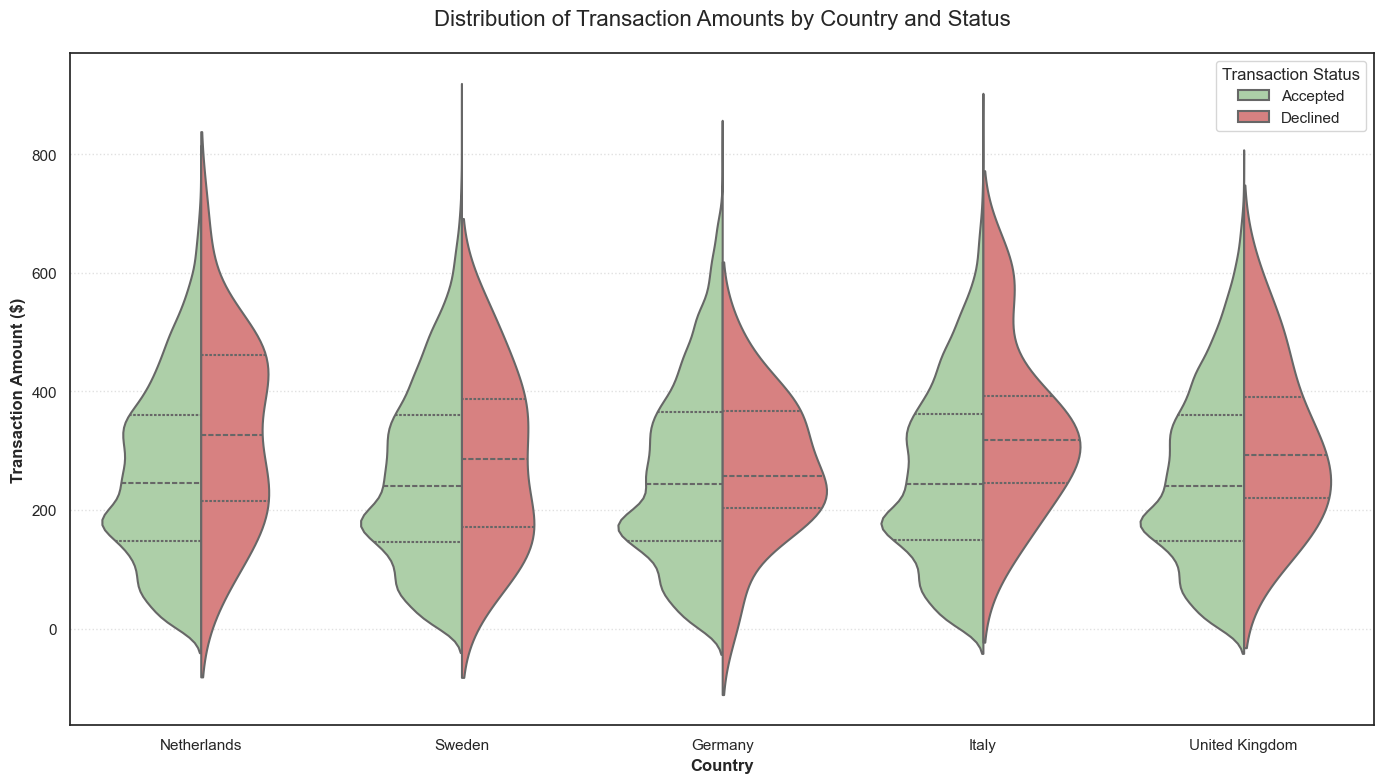

In [14]:
# Merge transactions with companies to get the country field
df = transactions.merge(companies[['company_id', 'country']], on='company_id', how='left')
# Ensure 'amount' is numeric and handle missing values
df['amount'] = pd.to_numeric(df['amount'], errors='coerce').fillna(0)

# Map 0 and 1 to readable names for the legend
df['Status'] = df['declined'].map({0: 'Accepted', 1: 'Declined'})

# Filtering (Top 5 countries by volume to avoid over-crowding)
top_countries = df['country'].value_counts().nlargest(5).index
df_filtered = df[df['country'].isin(top_countries)]

#  Aesthetic Configuration
plt.figure(figsize=(14, 8))
sns.set_style("white")

# Violin Plot Creation
# 'split=True' allows showing Accepted on one side and Declined on the other of the same violin
ax = sns.violinplot(
    data=df_filtered,
    x='country',
    y='amount',
    hue='Status',
    split=True,
    inner="quart",  # Shows quartile lines inside the violin
    palette={'Accepted': '#a8d5a2', 'Declined': '#e57373'},
    linewidth=1.5
)

plt.title('Distribution of Transaction Amounts by Country and Status', fontsize=16, pad=20)
plt.xlabel('Country', fontsize=12, fontweight='bold')
plt.ylabel('Transaction Amount ($)', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(title='Transaction Status', loc='upper right')
plt.tight_layout()

plt.show()

pariplot

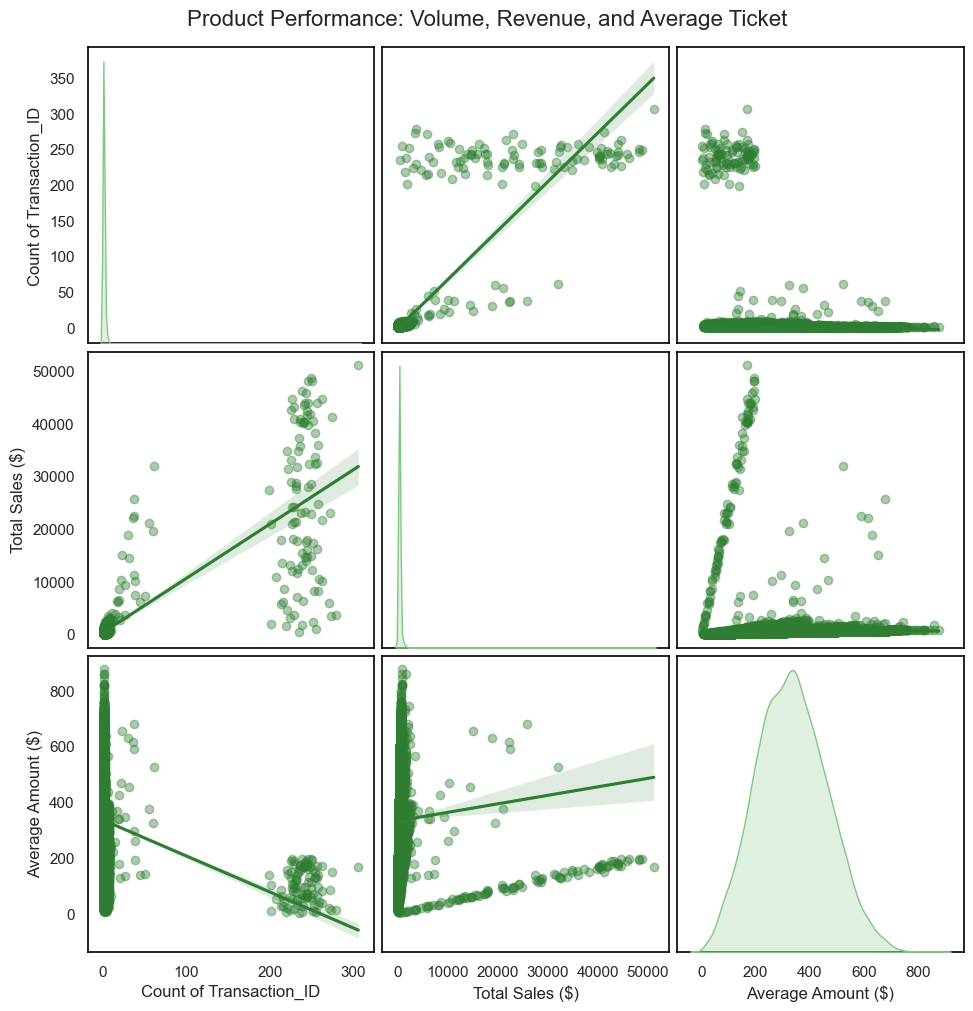

In [15]:
# Added 'mean' for the amount column
df_salesdetails = transactions.groupby('product_id').agg(
    {
        'transaction_id': 'count',
        'amount': ['sum', 'mean']
    }
).reset_index()

# Flatten the multi-index columns created by .agg
df_salesdetails.columns = ['product_id', 'Count of Transaction_ID', 'Total Sales ($)', 'Average Amount ($)']

# plot

sns.set_theme(style="white")
g = sns.pairplot(
    df_salesdetails[['Count of Transaction_ID', 'Total Sales ($)', 'Average Amount ($)']],
    kind='reg',
    diag_kind='kde',
    height=3.3,
    plot_kws={'color': '#2e7d32', 'scatter_kws': {'alpha': 0.4}},
    diag_kws={'color': '#81c784'}
)

# Adding Black Frames to each subplot
for ax in g.axes.flatten():
    if ax:
        plt.setp(ax.spines.values(), visible=True, edgecolor='black', linewidth=1.2)

g.figure.suptitle('Product Performance: Volume, Revenue, and Average Ticket', fontsize=16, y=1.02)
plt.show()

### nivel 2 matriz correlacion


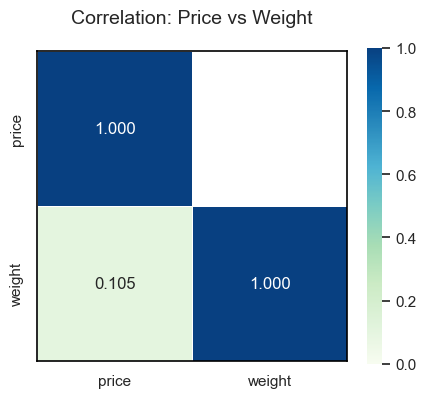

In [16]:
# Calculate the correlation matrix
corr_matrix = products[['price', 'weight']].corr()

# Create the mask for the upper triangle
# np.triu selects the upper triangle.
# k=1 ensures the main diagonal (where values are 1.000) is NOT hidden.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(5, 5))

# Generate Heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='GnBu',
    vmin=0,        # Scale starts at 0
    vmax=1,        # Scale ends at 1
    fmt='.3f',
    square=True,
    linewidths=.5,
    # 'shrink' adjusts the height of the colorbar to match the square plot
    cbar_kws={"shrink": .82}
)

plt.title("Correlation: Price vs Weight", fontsize=14, pad=20)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

plt.show()

jointplot


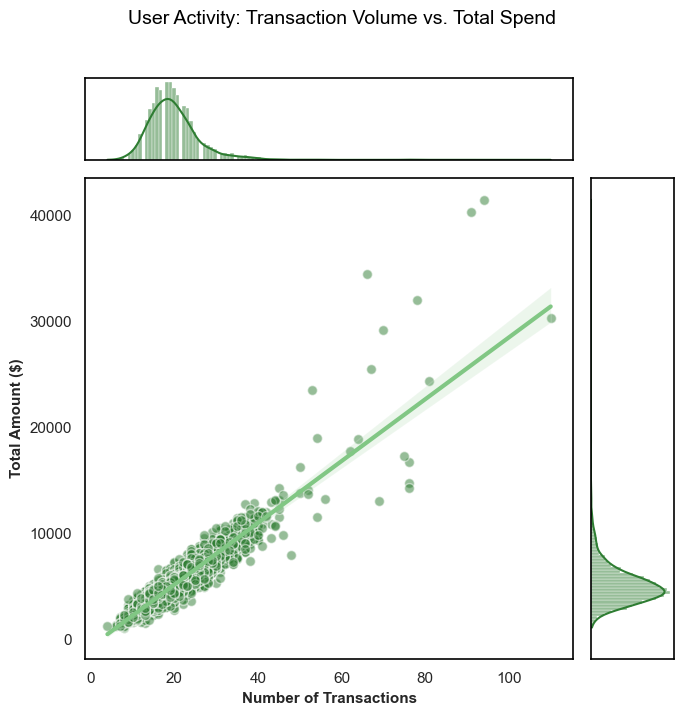

In [17]:

# Convert amount to numeric preventive
transactions['amount'] = pd.to_numeric(transactions['amount'], errors='coerce')

# Group data by user
df_grouped = transactions.groupby('user_id').agg(
    total_amount=('amount', 'sum'),
    number_of_transactions=('transaction_id', 'count')
).reset_index()

sns.set_theme(style="white")

#  Jointplot
g = sns.jointplot(
    data=df_grouped,
    x="number_of_transactions",
    y="total_amount",
    kind="reg",           # Adds regression line and marginal distributions
    height=7,
    color="#2e7d32",
    scatter_kws={'alpha': 0.5, 's': 50, 'edgecolor': 'white'},
    line_kws={'color': '#81c784', 'lw': 3}
)

g.set_axis_labels("Number of Transactions", "Total Amount ($)", fontsize=11, weight="bold")

# Add black frames to the main plot and the marginal plots
for ax in [g.ax_joint, g.ax_marg_x, g.ax_marg_y]:
    plt.setp(ax.spines.values(), visible=True, edgecolor='black', linewidth=1.2)

g.figure.suptitle(
    "User Activity: Transaction Volume vs. Total Spend",
    fontsize=14,
    y=1.02,
    color="black"
)

plt.tight_layout()
plt.show()

nivel 3

In [ ]:
# I store my dataframes in a csv to work then whith them in PBI

In [24]:
for df_name, df in dictionary_of_dfs.items():
    df["id_unico"] = df.index
    df.to_csv(f"{df_name}.csv", index = False)

In [25]:
import os
os.getcwd()


'C:\\code\\CURSOS\\BOOTCAMP_DATA_IT ACADEMY_2025_2026\\sprint_11\\tarea_s11_1_sprint_11'